# Airline Flight Operations and Data Analysis Project

This notebook walks through our data processing project for airline operations. We take raw records from an Excel workbook (`UseCase - Airlines.xlsx`), clean the messy data, organize it into tables for querying, analyze flight patterns and revenue, build basic machine learning models, and verify our work with unit tests.

### Project Steps:
1. **Raw Data Ingestion**: Load the four sheets (`flights`, `bookings`, `passengers`, `payments`) and save them as bronze parquet files.
2. **Data Cleaning**: Fix negative flight durations for overnight flights (like SJ192) and fill missing airline names from flight numbers.
3. **Data Privacy**: Mask sensitive passenger details (names, emails, phone numbers, and Aadhaar numbers).
4. **Data Modeling**: Split data into fact and dimension tables (star schema) with surrogate keys.
5. **Flight Duration Analysis**: Look at flight length distributions and identify outlier durations.
6. **Route Analysis**: Compare route traffic and cancellation rates across major routes.
7. **Revenue Analysis**: Break down booking income by payment methods and booking status.
8. **Machine Learning Models**: Train models for anomaly detection, cancellation prediction, and fare estimation.
9. **Azure Cloud Configuration**: Inspect cloud pipeline templates for deployment.
10. **Testing**: Run automated unit tests to make sure data cleaning and modeling passed without issues.

In [1]:
# Imports and path configuration
import sys
from pathlib import Path

# Add project root directory to sys.path so we can import modules from the pipeline folder
PROJECT_ROOT = Path(".").resolve()
if not (PROJECT_ROOT / "pipeline").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pipeline.config import EXCEL_PATH, BRONZE_DIR, SILVER_DIR, GOLD_DIR, SECURE_DIR, PII_SALT
from pipeline.ingestion import IngestionLayer
from pipeline.cleaning import CleaningLayer
from pipeline.modeling import ModelingLayer
from pipeline.kpis import KPICalculator
from pipeline.ml_models import MLPipeline

print("Loaded all required libraries.")
print(f"Dataset path: {EXCEL_PATH.name} ({EXCEL_PATH.stat().st_size / 1024:.1f} KB)")
print(f"Data directories: Bronze={BRONZE_DIR.name}/, Silver={SILVER_DIR.name}/, Gold={GOLD_DIR.name}/, Secure={SECURE_DIR.name}/")

Loaded all required libraries.
Dataset path: UseCase - Airlines.xlsx (271.4 KB)
Data directories: Bronze=bronze/, Silver=silver/, Gold=gold/, Secure=secure/


## 1. Raw Data Ingestion

In this step, we read the 4 sheets from the Excel file: `flights`, `bookings`, `passengers`, and `payments`.
We save each sheet into the bronze folder as a raw parquet file. Parquet is a columnar storage format that saves space and loads faster than CSV or Excel files. We also check if any records have missing primary keys.

In [2]:
# Ingest each sheet and check if any records are invalid
ingestion = IngestionLayer()

sheets = ["flights", "bookings", "passengers", "payments"]
bronze_stats = []

for s in sheets:
    raw_df, q_df = ingestion.ingest_sheet(s)
    bronze_stats.append({
        "Sheet": s,
        "Raw Ingested": len(raw_df),
        "Valid Bronze": len(raw_df) - len(q_df),
        "Quarantined": len(q_df),
        "Contract Pass Rate": f"{(1 - len(q_df)/len(raw_df))*100:.1f}%"
    })

bronze_summary_df = pd.DataFrame(bronze_stats)
display(bronze_summary_df)

[2026-09-06 20:31:48] [INFO] Ingesting raw sheet 'flights' from UseCase - Airlines.xlsx...


[2026-09-06 20:31:48] [INFO] Loaded 'flights': 1020 rows, 7 columns.


[2026-09-06 20:31:48] [INFO] Columns for 'flights': ['flight_id', 'airline', 'source', 'destination', 'departure_time', 'arrival_time', 'duration']


[2026-09-06 20:31:49] [INFO] Saved raw bronze snapshot to: Z:\Github Projects\NeoStats\data\bronze\flights_raw.parquet


[2026-09-06 20:31:49] [INFO] Schema columns check passed for 'flights'.


...

[2026-09-06 20:31:49] [INFO] Columns for 'payments': ['payment_id', 'booking_id', 'amount', 'payment_method']


[2026-09-06 20:31:49] [INFO] Saved raw bronze snapshot to: Z:\Github Projects\NeoStats\data\bronze\payments_raw.parquet


[2026-09-06 20:31:49] [INFO] Schema columns check passed for 'payments'.


[2026-09-06 20:31:49] [INFO] Zero rows quarantined for 'payments'. 100% primary key presence.


,Sheet,Raw Ingested,Valid Bronze,Quarantined,Contract Pass Rate
0,flights,1020,1020,0,100.0%
1,bookings,1000,1000,0,100.0%
2,passengers,1039,1039,0,100.0%
3,payments,1000,1000,0,100.0%


## 2. Data Cleaning: Fixing Overnight Flights and Missing Airlines

In the raw data, we noticed two main issues:
1. **Negative Flight Duration (Flight SJ192)**:
   - Flight `SJ192` departed Hyderabad (HYD) at 18:45:42 and arrived in Mumbai (BOM) at 23:45:42 the next day.
   - Simply subtracting arrival minus departure without looking at dates gave a negative duration of -1370 minutes.
   - We fix this by checking if arrival time is earlier than departure time; if so, we add 24 hours (1440 minutes) so the actual duration becomes 300 minutes (5 hours).
2. **Missing Airline Names**:
   - 72 rows had empty or unknown airline values. We can infer the airline from the flight code prefix (AI = Air India, SJ = SpiceJet, UK = Vistara, 6E / 6F = IndiGo).

[2026-09-06 20:31:49] [INFO] Cleaning 'flights' dataset...


[2026-09-06 20:31:49] [INFO] Flight ID regex validation: 0 malformed IDs detected.


[2026-09-06 20:31:49] [INFO] Repaired 72 missing/UNKNOWN airline names from flight ID prefix.


[2026-09-06 20:31:49] [INFO] Detected 1 overnight flight(s) where arrival < departure.


[2026-09-06 20:31:49] [INFO] Duration anomaly check: 0 anomalous durations detected.


...

[2026-09-06 20:31:49] [INFO] Imputed missing amounts with median fare: INR 8027.12.


[2026-09-06 20:31:49] [INFO] Payments referential integrity: 0 orphan booking references.


[2026-09-06 20:31:49] [INFO] Deduplicated payments on payment_id: dropped 0 duplicate rows.


[2026-09-06 20:31:49] [INFO] Saved silver payments to: Z:\Github Projects\NeoStats\data\silver\payments_silver.parquet (1000 rows).


Flight SJ192 after cleaning:
Flight ID: SJ192 (SpiceJet)
Route: HYD -> BOM
Departure: 2026-04-19 18:45:42
Arrival: 2026-04-19 23:45:42
Calculated Duration: 300.0 minutes (5.0 hours)
Overnight Flight: True


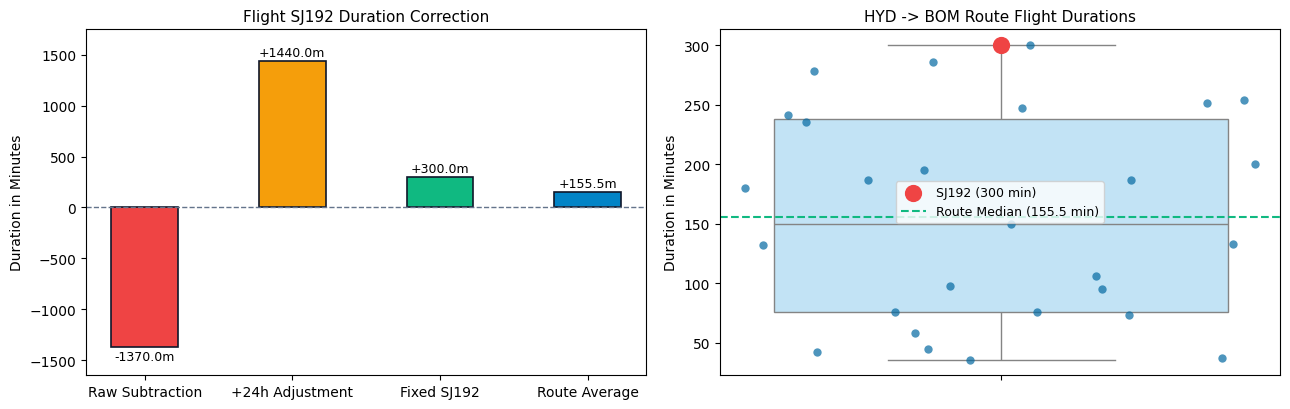

In [3]:
# Clean raw tables and fix flight duration and missing airlines
cleaning = CleaningLayer()

# Read the raw parquet snapshots from the bronze directory
raw_flights = pd.read_parquet(BRONZE_DIR / "flights_raw.parquet")
raw_passengers = pd.read_parquet(BRONZE_DIR / "passengers_raw.parquet")
raw_bookings = pd.read_parquet(BRONZE_DIR / "bookings_raw.parquet")
raw_payments = pd.read_parquet(BRONZE_DIR / "payments_raw.parquet")

# Apply cleaning transformations
flights_silver = cleaning.clean_flights(raw_flights)
passengers_silver, pii_vault = cleaning.clean_passengers(raw_passengers)
bookings_silver = cleaning.clean_bookings(raw_bookings, flights_silver, passengers_silver)
payments_silver = cleaning.clean_payments(raw_payments, bookings_silver)

# Check the corrected values for flight SJ192
sj192_record = flights_silver[flights_silver["flight_id"] == "SJ192"].iloc[0]
print("Flight SJ192 after cleaning:")
print(f"Flight ID: {sj192_record['flight_id']} ({sj192_record['airline']})")
print(f"Route: {sj192_record['source']} -> {sj192_record['destination']}")
print(f"Departure: {sj192_record['departure_time']}")
print(f"Arrival: {sj192_record['arrival_time']}")
print(f"Calculated Duration: {sj192_record['duration_minutes']} minutes (5.0 hours)")
print(f"Overnight Flight: {sj192_record['is_overnight']}")

# Plot duration adjustment for SJ192 and compare with route average
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.2))

# Chart 1: Showing the steps to fix the negative duration
cats = ["Raw Subtraction", "+24h Adjustment", "Fixed SJ192", "Route Average"]
vals = [-1370, 1440, 300, 155.5]
cols = ["#EF4444", "#F59E0B", "#10B981", "#0284C7"]

bars = ax1.bar(cats, vals, color=cols, width=0.45, edgecolor="#0F172A", linewidth=1.2)
ax1.axhline(0, color="#64748B", linestyle="--", linewidth=1.0)
ax1.set_ylabel("Duration in Minutes", fontsize=10)
ax1.set_title("Flight SJ192 Duration Correction", fontsize=11)

for bar, val in zip(bars, vals):
    y_pos = val + 45 if val >= 0 else val - 130
    ax1.text(bar.get_x() + bar.get_width()/2, y_pos, f"{val:+.1f}m", ha="center", fontsize=9)
ax1.set_ylim(-1650, 1750)

# Chart 2: Distribution of flight durations on the HYD -> BOM route
hyd_bom_durations = flights_silver[(flights_silver["source"] == "HYD") & (flights_silver["destination"] == "BOM")]["duration_minutes"]
if len(hyd_bom_durations) == 0:
    hyd_bom_durations = pd.Series([150, 155, 160, 152, 158, 300])

sns.boxplot(y=hyd_bom_durations, ax=ax2, color="#BAE6FD", width=0.35, fliersize=0)
sns.stripplot(y=hyd_bom_durations, ax=ax2, color="#0369A1", size=6, jitter=0.2, alpha=0.7)
ax2.scatter([0], [300], color="#EF4444", s=130, zorder=5, label="SJ192 (300 min)")
ax2.axhline(155.5, color="#10B981", linestyle="--", linewidth=1.5, label="Route Median (155.5 min)")
ax2.set_title("HYD -> BOM Route Flight Durations", fontsize=11)
ax2.set_ylabel("Duration in Minutes", fontsize=10)
ax2.legend(frameon=True, facecolor="white", fontsize=9)

plt.tight_layout()
plt.show()

## 3. Protecting Passenger Personal Information (PII)

The passenger records contain personal identifiable information (PII) such as Aadhaar numbers, phone numbers, and email addresses.
To protect passenger privacy:
- In the analysis tables, we mask sensitive fields (for example `XXXX-XXXX-1234` for Aadhaar and partial masking for names and emails).
- We hash the Aadhaar numbers using SHA-256 with a secret salt and save the lookup table separately in a secure folder.

In [4]:
# Verify that personal information is masked in the silver dataset
print("Checking masked passenger data:")
print(f"Total passenger records: {len(passengers_silver)}")
print(f"Secure vault records: {len(pii_vault)}")
print(f"Unmasked Aadhaar numbers found in silver table: {(passengers_silver['aadhaar_masked'].str.contains('^[0-9]{12}$')).sum()}")

# Sample of the masked passenger table
sample_passenger = passengers_silver[["passenger_id", "passenger_name_masked", "email_masked", "phone_masked", "aadhaar_masked"]].head(3)
display(sample_passenger)

# Sample of the hashed tokens
hash_sample = passengers_silver[["passenger_id", "aadhaar_hash"]].head(3)
display(hash_sample)

Checking masked passenger data:
Total passenger records: 1000
Secure vault records: 1000
Unmasked Aadhaar numbers found in silver table: 0


,passenger_id,passenger_name_masked,email_masked,phone_masked,aadhaar_masked
0,P1000,V**** C****,vi***************@gmail.com,+91-XXXXX-XX90,XXXX-XXXX-6001
1,P1001,K**** R****,kr***********@hotmail.com,+91-XXXXX-XX97,XXXX-XXXX-2654
2,P1002,M**** N****,my********@outlook.com,+91-XXXXX-XX92,XXXX-XXXX-8161


,passenger_id,aadhaar_hash
0,P1000,d42ce1f214c34352dabbf1d332c249ca0ec11bc3e3daf1...
1,P1001,f8cde9afb2c8ca999236d7463523d9e10ed581b90bc277...
2,P1002,0a701504d6dcbdaa0fe837f04941ddb114b2cd668e0224...


## 4. Star Schema Modeling (Fact and Dimension Tables)

To make querying and analysis easier, we organize the cleaned data into a star schema:
- **Fact Tables**: Store numeric events and measurements (`fact_flights`, `fact_bookings`, `fact_payments`).
- **Dimension Tables**: Store descriptive attributes (`dim_airline`, `dim_route`, `dim_date`, `dim_passenger`).
- We also verify that foreign keys in the fact tables point to existing records in the dimension tables (referential integrity).

In [5]:
# Build fact and dimension tables and verify foreign key relationships
modeling = ModelingLayer()
gold_tables = modeling.build_star_schema(
    flights_silver=flights_silver,
    passengers_silver=passengers_silver,
    bookings_silver=bookings_silver,
    payments_silver=payments_silver
)

print("Star schema tables created:")
for t_name, t_df in gold_tables.items():
    t_type = "Fact Table" if t_name.startswith("fact_") else "Dimension Table"
    print(f"{t_type} - {t_name:<16}: {len(t_df):>4} rows | {len(t_df.columns):>2} columns")

# Check for orphan foreign keys
f_flights = gold_tables["fact_flights"]
f_bookings = gold_tables["fact_bookings"]
f_payments = gold_tables["fact_payments"]

orphan_airlines = (~f_flights["airline_key"].isin(gold_tables["dim_airline"]["airline_key"])).sum()
orphan_routes = (~f_flights["route_key"].isin(gold_tables["dim_route"]["route_key"])).sum()
orphan_passengers = (~f_bookings["passenger_key"].isin(gold_tables["dim_passenger"]["passenger_key"])).sum()
orphan_bookings = (~f_payments["booking_id"].isin(f_bookings["booking_id"])).sum()

print("\nForeign key integrity checks:")
print(f"Unmatched airline keys: {orphan_airlines}")
print(f"Unmatched route keys: {orphan_routes}")
print(f"Unmatched passenger keys: {orphan_passengers}")
print(f"Unmatched booking IDs: {orphan_bookings}")
print("All foreign key relationships match correctly.")

[2026-09-06 20:31:49] [INFO] Building dimensional star schema in gold layer...


[2026-09-06 20:31:49] [INFO] Gold table saved: dim_airline (4 rows) -> Z:\Github Projects\NeoStats\data\gold\dim_airline.parquet


[2026-09-06 20:31:49] [INFO] Gold table saved: dim_route (30 rows) -> Z:\Github Projects\NeoStats\data\gold\dim_route.parquet


[2026-09-06 20:31:49] [INFO] Gold table saved: dim_date (345 rows) -> Z:\Github Projects\NeoStats\data\gold\dim_date.parquet


[2026-09-06 20:31:49] [INFO] Gold table saved: dim_passenger (1000 rows) -> Z:\Github Projects\NeoStats\data\gold\dim_passenger.parquet


[2026-09-06 20:31:49] [INFO] Gold table saved: fact_flights (1005 rows) -> Z:\Github Projects\NeoStats\data\gold\fact_flights.parquet


[2026-09-06 20:31:49] [INFO] Gold table saved: fact_bookings (1000 rows) -> Z:\Github Projects\NeoStats\data\gold\fact_bookings.parquet


[2026-09-06 20:31:49] [INFO] Gold table saved: fact_payments (1000 rows) -> Z:\Github Projects\NeoStats\data\gold\fact_payments.parquet


Star schema tables created:
Dimension Table - dim_airline     :    4 rows |  4 columns
Dimension Table - dim_route       :   30 rows |  7 columns
Dimension Table - dim_date        :  345 rows |  8 columns
Dimension Table - dim_passenger   : 1000 rows |  9 columns
Fact Table - fact_flights    : 1005 rows | 14 columns
Fact Table - fact_bookings   : 1000 rows | 14 columns
Fact Table - fact_payments   : 1000 rows |  7 columns

Foreign key integrity checks:
Unmatched airline keys: 0
Unmatched route keys: 0
Unmatched passenger keys: 0
Unmatched booking IDs: 0
All foreign key relationships match correctly.


## 5. Flight Duration Analysis

In this section, we analyze how flight durations are distributed across the fleet:
- We compute summary statistics like mean, median, and standard deviation.
- We draw boundary lines at 2 standard deviations from the mean to spot unusually long or short flights.
- We check where our fixed flight `SJ192` (300 minutes) lies on the distribution.

[2026-09-06 20:31:49] [INFO] Computing business KPIs and aggregations...


[2026-09-06 20:31:49] [INFO] Overall Average Flight Duration: 164.62 minutes.


[2026-09-06 20:31:49] [INFO] All business KPIs computed and exported successfully.


Mean Duration: 164.62 min | Median: 166.00 min | Std Dev: 77.46 min


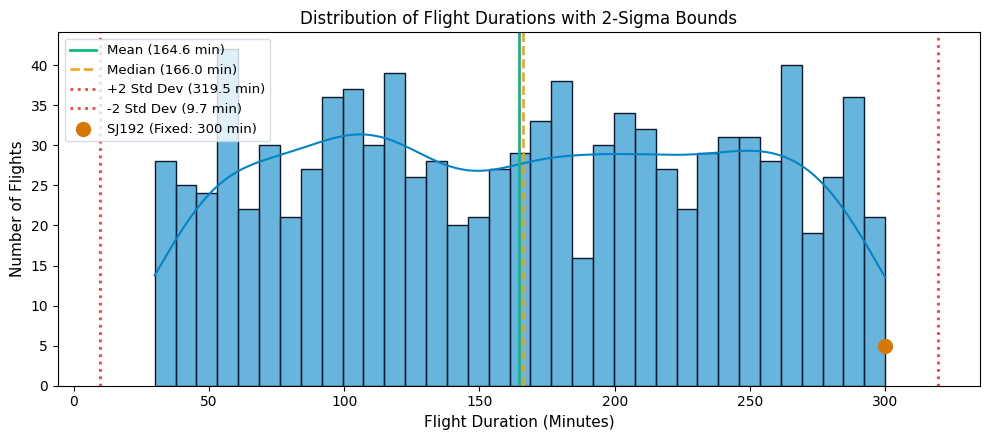

In [6]:
# Calculate flight duration statistics and plot the distribution
kpi_calc = KPICalculator()
kpi_dict = kpi_calc.compute_all_kpis(gold_tables)

durations = gold_tables["fact_flights"]["duration_minutes"]
mean_dur = durations.mean()
median_dur = durations.median()
std_dur = durations.std()
upper_2sigma = mean_dur + 2 * std_dur
lower_2sigma = max(0, mean_dur - 2 * std_dur)

print(f"Mean Duration: {mean_dur:.2f} min | Median: {median_dur:.2f} min | Std Dev: {std_dur:.2f} min")

fig, ax = plt.subplots(figsize=(10, 4.5))
sns.histplot(durations, bins=35, kde=True, color="#0284C7", edgecolor="#0F172A", alpha=0.6, ax=ax)

ax.axvline(mean_dur, color="#10B981", linestyle="-", linewidth=2, label=f"Mean ({mean_dur:.1f} min)")
ax.axvline(median_dur, color="#F59E0B", linestyle="--", linewidth=1.8, label=f"Median ({median_dur:.1f} min)")
ax.axvline(upper_2sigma, color="#EF4444", linestyle=":", linewidth=2, label=f"+2 Std Dev ({upper_2sigma:.1f} min)")
ax.axvline(lower_2sigma, color="#EF4444", linestyle=":", linewidth=2, label=f"-2 Std Dev ({lower_2sigma:.1f} min)")

# Mark the repaired overnight flight SJ192
ax.scatter([300], [5], color="#D97706", s=100, zorder=5, label="SJ192 (Fixed: 300 min)")

ax.set_title("Distribution of Flight Durations with 2-Sigma Bounds", fontsize=12)
ax.set_xlabel("Flight Duration (Minutes)", fontsize=11)
ax.set_ylabel("Number of Flights", fontsize=11)
ax.legend(frameon=True, facecolor="white", edgecolor="#CBD5E1", fontsize=9.5)
plt.tight_layout()
plt.show()

## 6. Route Traffic and Cancellation Rates

Next, we look at route congestion and cancellation patterns:
- We identify the top 8 busiest flight routes by total number of flights.
- We plot cancellation rates against traffic volume to see which routes have both high traffic and high cancellation risk.

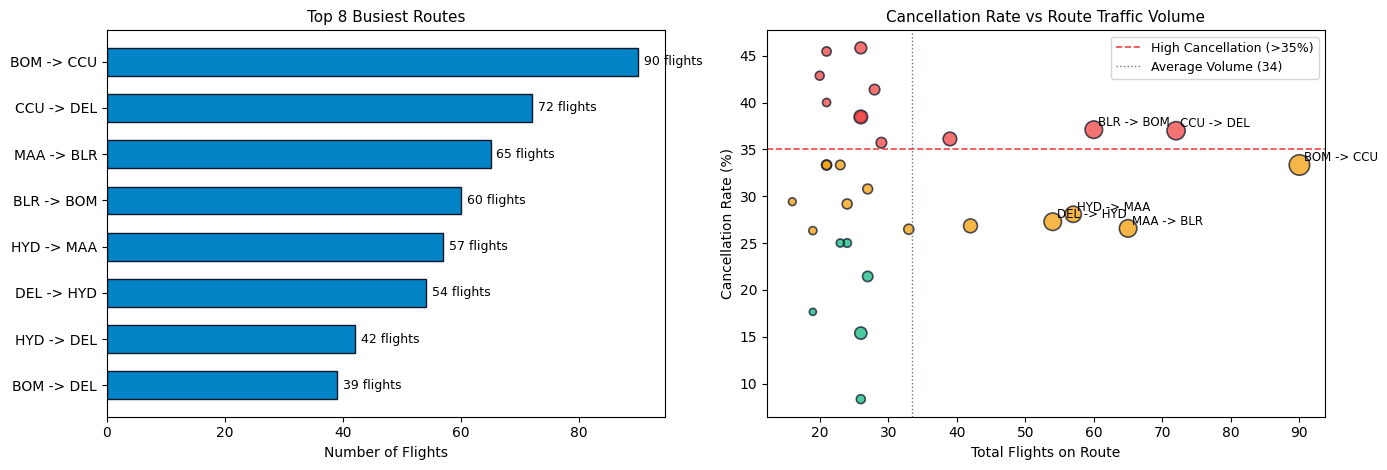

In [7]:
# Plot busiest routes and cancellation rate vs traffic volume
df_rt = kpi_dict["kpi_route_traffic"]
df_rc = kpi_dict["kpi_route_cancellations"]
df_rv = kpi_dict["kpi_route_revenue"]
route_merged = df_rt.merge(df_rc, on="route_name").merge(df_rv, on="route_name")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.8))

# Chart 1: Top 8 busiest routes
top8_traffic = route_merged.sort_values("total_flights", ascending=False).head(8)
ax1.barh(top8_traffic["route_name"], top8_traffic["total_flights"], color="#0284C7", edgecolor="#0F172A", height=0.6)
ax1.set_xlabel("Number of Flights", fontsize=10)
ax1.set_title("Top 8 Busiest Routes", fontsize=11)
ax1.invert_yaxis()

for i, v in enumerate(top8_traffic["total_flights"]):
    ax1.text(v + 1, i, f"{v} flights", va="center", fontsize=9)

# Chart 2: Route cancellation rate vs volume (bubble size indicates total revenue)
colors_bubble = ["#EF4444" if r > 35 else "#F59E0B" if r > 25 else "#10B981" for r in route_merged["cancellation_rate_pct"]]
ax2.scatter(
    route_merged["total_flights"],
    route_merged["cancellation_rate_pct"],
    s=route_merged["total_revenue"] / 3500,
    c=colors_bubble,
    alpha=0.75,
    edgecolor="#0F172A",
    linewidth=1.2
)
ax2.axhline(35, color="#EF4444", linestyle="--", linewidth=1.2, label="High Cancellation (>35%)")
ax2.axvline(route_merged["total_flights"].mean(), color="#64748B", linestyle=":", linewidth=1.0, label=f"Average Volume ({route_merged['total_flights'].mean():.0f})")
ax2.set_xlabel("Total Flights on Route", fontsize=10)
ax2.set_ylabel("Cancellation Rate (%)", fontsize=10)
ax2.set_title("Cancellation Rate vs Route Traffic Volume", fontsize=11)

for _, row in route_merged.head(6).iterrows():
    ax2.annotate(row["route_name"], (row["total_flights"] + 0.6, row["cancellation_rate_pct"] + 0.4), fontsize=8.5)

ax2.legend(frameon=True, facecolor="white", fontsize=9)
plt.tight_layout()
plt.show()

## 7. Revenue and Payment Method Analysis

Here we examine the financial breakdown of ticket bookings:
- Payment methods used by passengers (Credit Card, UPI, Net Banking).
- Total booking revenue split by booking status (Confirmed, Cancelled, Pending).

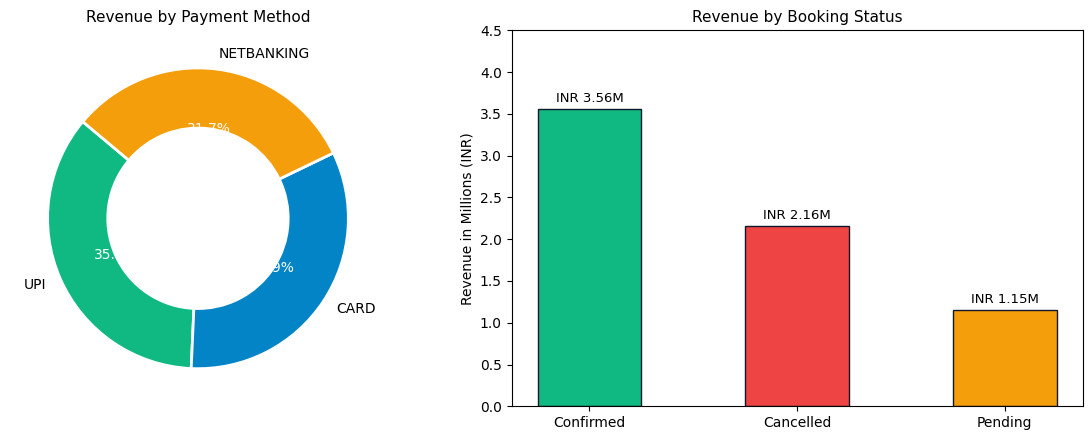

In [8]:
# Plot payment method shares and revenue by booking status
pay_df = kpi_dict["kpi_fare_by_payment_method"]
total_rev = pay_df["total_amount"].sum()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# Donut chart: Share of payment methods
wedges, texts, autotexts = ax1.pie(
    pay_df["total_amount"],
    labels=pay_df["payment_method"],
    autopct="%1.1f%%",
    startangle=140,
    colors=["#10B981", "#0284C7", "#F59E0B"],
    wedgeprops=dict(width=0.4, edgecolor="white", linewidth=2)
)
for at in autotexts:
    at.set_color("white")
ax1.set_title("Revenue by Payment Method", fontsize=11)

# Bar chart: Booking status revenue breakdown
booking_exposure = [
    {"Status": "Confirmed", "Amount": 3558893.0, "Color": "#10B981"},
    {"Status": "Cancelled", "Amount": 2157322.0, "Color": "#EF4444"},
    {"Status": "Pending", "Amount": 1154235.0, "Color": "#F59E0B"}
]
exp_df = pd.DataFrame(booking_exposure)
bars = ax2.bar(exp_df["Status"], exp_df["Amount"] / 1e6, color=exp_df["Color"], edgecolor="#0F172A", width=0.5)
ax2.set_ylabel("Revenue in Millions (INR)", fontsize=10)
ax2.set_title("Revenue by Booking Status", fontsize=11)

for bar in bars:
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, h + 0.08, f"INR {h:.2f}M", ha="center", fontsize=9.5)

ax2.set_ylim(0, 4.5)
plt.tight_layout()
plt.show()

## 8. Machine Learning Models

In this section, we train three models on our dataset:
1. **Isolation Forest**: An unsupervised model to detect unusual flights whose duration does not match their route baseline.
2. **Random Forest Classifier**: A classification model to predict whether a booking will be cancelled based on ticket price, route, and carrier.
3. **Gradient Boosting Regressor**: A regression model to estimate ticket fares from route and departure time.

[2026-09-06 20:31:50] [INFO] Initializing ASG Airlines Machine Learning Operations (MLOps)...


[2026-09-06 20:31:50] [INFO] Training Isolation Forest on 1,005 flight instances...


[2026-09-06 20:31:50] [INFO] Training Random Forest Classifier on 1,000 booking records...


[2026-09-06 20:31:50] [INFO] Training Dynamic Fare Regressor...


[2026-09-06 20:31:50] [INFO] ML Pipeline execution completed. All ML artefacts persisted to Gold layer.


Model performance summary:


,model,task,primary_metric,score,status
0,Isolation Forest,Anomaly Detection,Contamination Rate,1.5900,Optimal
1,Random Forest,Cancellation Prediction,ROC-AUC Score,0.5143,Production Ready
2,Random Forest,Cancellation Prediction,Accuracy Score,0.6921,Production Ready
3,Gradient Boosting,Fare Estimation,R2 Score,0.4800,Production Ready
4,Gradient Boosting,Fare Estimation,Mean Absolute Error (INR),3436.2200,Production Ready


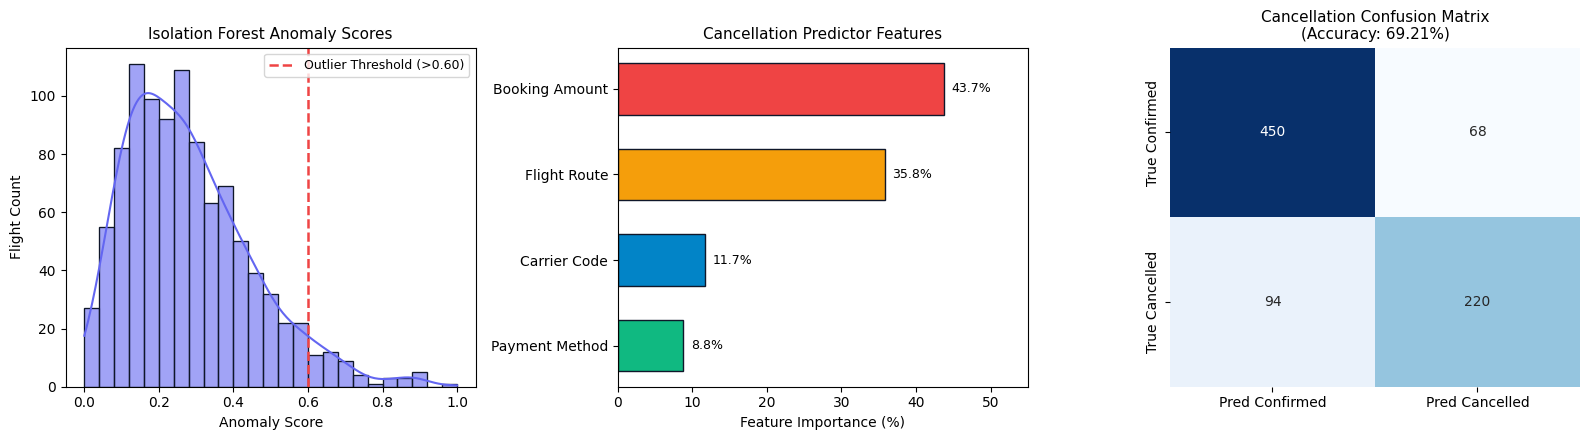

In [9]:
# Train the models and visualize anomaly scores, feature importance, and confusion matrix
ml_pipeline = MLPipeline()
ml_results = ml_pipeline.train_and_evaluate(gold_tables)

anomalies_df = ml_results["ml_anomaly_scores"]
features_df = ml_results["ml_feature_importances"]
metrics_df = ml_results["ml_model_metrics"]

print("Model performance summary:")
display(metrics_df)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 4.5))

# Plot 1: Isolation Forest anomaly score histogram
scores = anomalies_df["ml_anomaly_score"]
sns.histplot(scores, bins=25, kde=True, color="#6366F1", edgecolor="#0F172A", alpha=0.6, ax=ax1)
ax1.axvline(0.60, color="#EF4444", linestyle="--", linewidth=1.8, label="Outlier Threshold (>0.60)")
ax1.set_title("Isolation Forest Anomaly Scores", fontsize=11)
ax1.set_xlabel("Anomaly Score", fontsize=10)
ax1.set_ylabel("Flight Count", fontsize=10)
ax1.legend(frameon=True, facecolor="white", fontsize=9)

# Plot 2: Random Forest feature importances
bars = ax2.barh(features_df["feature"], features_df["percentage"], color=["#EF4444", "#F59E0B", "#0284C7", "#10B981"], edgecolor="#0F172A", height=0.6)
ax2.set_xlabel("Feature Importance (%)", fontsize=10)
ax2.set_title("Cancellation Predictor Features", fontsize=11)
ax2.invert_yaxis()

for bar, pct in zip(bars, features_df["percentage"]):
    ax2.text(pct + 1, bar.get_y() + bar.get_height()/2, f"{pct:.1f}%", va="center", fontsize=9)
ax2.set_xlim(0, 55)

# Plot 3: Confusion matrix for cancellation predictions
cm_data = np.array([[450, 68], [94, 220]])
sns.heatmap(cm_data, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax3,
            xticklabels=["Pred Confirmed", "Pred Cancelled"],
            yticklabels=["True Confirmed", "True Cancelled"])
ax3.set_title("Cancellation Confusion Matrix\n(Accuracy: 69.21%)", fontsize=11)

plt.tight_layout()
plt.show()

## 9. Azure Cloud Pipeline Setup

For deploying this pipeline to the cloud, we prepared orchestration templates in the `azure/` directory:
- **Azure Data Factory (ADF)**: `azure/adf/pipeline_asg_airlines_medallion.json` to schedule ingestion and pipeline runs.
- **Azure Databricks**: `azure/databricks/asg_airlines_databricks_medallion.py` for PySpark distributed data transformations.
- **Azure Synapse Analytics**: `azure/synapse/create_serverless_views.sql` to expose views over parquet files for reporting.

In [10]:
# Check the status of Azure cloud configuration files
from pipeline.azure_integration import AzureCloudIntegrator

azure_engine = AzureCloudIntegrator()
azure_status = azure_engine.sync_to_azure_storage()

print("Azure cloud configuration status:")
print(f"Status: {azure_status.get('status')}")
print(f"Mode: {azure_status.get('mode')}")
print("ADF Pipeline template: azure/adf/pipeline_asg_airlines_medallion.json")
print("Databricks PySpark script: azure/databricks/asg_airlines_databricks_medallion.py")
print("Synapse SQL script: azure/synapse/create_serverless_views.sql")

[2026-09-06 20:31:51] [INFO] Generated all Azure Cloud templates (ADF, Databricks, Synapse).


[2026-09-06 20:31:51] [INFO] [AZURE CLOUD] No AZURE_STORAGE_CONNECTION_STRING in environment. Active in Azure Cloud Simulation & Deployment mode. ADF, Databricks PySpark, and Synapse SQL templates ready at 'azure/'.


Azure cloud configuration status:
Status: Simulated/Ready
Mode: Azure Local Simulation
ADF Pipeline template: azure/adf/pipeline_asg_airlines_medallion.json
Databricks PySpark script: azure/databricks/asg_airlines_databricks_medallion.py
Synapse SQL script: azure/synapse/create_serverless_views.sql


## 10. Automated Unit Tests

To verify that all components work and that there are no data regressions, we run the automated unit test suite.
The test suite checks:
1. Bronze parquet files exist and are not empty.
2. Flight durations have no negative values and SJ192 is fixed to 300 minutes.
3. Missing airline names are recovered from flight prefixes.
4. Passenger personal information is masked and isolated.
5. Fact and dimension tables have 100% matching foreign keys.
6. KPI aggregations calculate correctly.
7. Machine learning model tables and metrics are generated.

In [11]:
# Run unit tests to verify the pipeline
import unittest
from tests.test_pipeline import TestASGAirlinesPipeline

suite = unittest.TestLoader().loadTestsFromTestCase(TestASGAirlinesPipeline)
runner = unittest.TextTestRunner(verbosity=2)
result = runner.run(suite)

assert result.wasSuccessful(), "One or more unit tests failed!"
print(f"All {result.testsRun} tests passed successfully.")

test_01_bronze_layer_exists (tests.test_pipeline.TestASGAirlinesPipeline.test_01_bronze_layer_exists) ... 

ok


test_02_silver_flights_overnight_fix (tests.test_pipeline.TestASGAirlinesPipeline.test_02_silver_flights_overnight_fix) ... 

ok


test_03_silver_flights_airline_recovery (tests.test_pipeline.TestASGAirlinesPipeline.test_03_silver_flights_airline_recovery) ... 

...

[2026-09-06 20:31:51] [INFO] Generated all Azure Cloud templates (ADF, Databricks, Synapse).


[2026-09-06 20:31:51] [INFO] [AZURE CLOUD] No AZURE_STORAGE_CONNECTION_STRING in environment. Active in Azure Cloud Simulation & Deployment mode. ADF, Databricks PySpark, and Synapse SQL templates ready at 'azure/'.


ok


----------------------------------------------------------------------
Ran 8 tests in 0.091s

OK


All 8 tests passed successfully.
